In [ ]:
from sage.all import *
import random
import bisect
import math

In [13]:
import random
from functools import lru_cache

def sample_oscillating_C2(L, seed=None):
    """
    Uniform random oscillating tableau path of length L in the C2 chamber
    a >= b >= 0, starting and ending at (0,0).

    Returns a list of (a,b) positions of length L+1.
    """
    if L < 0 or L % 2 != 0:
        raise ValueError("L must be a nonnegative even integer.")

    rng = random.Random(seed)
    moves = ((1, 0), (0, 1), (-1, 0), (0, -1))

    @lru_cache(None)
    def cnt(a, b, r):
        if not (a >= b >= 0):
            return 0

        # Need at least a+b downward moves to return to (0,0),
        # and parity must match.
        s = a + b
        if r < s or (r - s) % 2:
            return 0

        if r == 0:
            return int((a, b) == (0, 0))

        total = 0
        for da, db in moves:
            total += cnt(a + da, b + db, r - 1)
        return total

    if cnt(0, 0, L) == 0:
        raise RuntimeError("No valid paths found.")

    path = [(0, 0)]
    a = b = 0

    for t in range(L):
        r = L - t - 1
        options = []

        for da, db in moves:
            na, nb = a + da, b + db
            c = cnt(na, nb, r)
            if c > 0:
                options.append((na, nb, c))

        total = sum(c for _, _, c in options)
        u = rng.randrange(total)

        acc = 0
        for na, nb, c in options:
            acc += c
            if u < acc:
                a, b = na, nb
                path.append((a, b))
                break

    assert path[-1] == (0, 0)
    return path

In [14]:
def oscillating_to_matching(path):
    """
    Convert a C2 oscillating tableau path into a matching.

    path is a list of pairs (a,b), with single-coordinate steps.
    Returns a list of pairs (open_time, close_time).
    """
    row0 = []
    row1 = []
    matchings = []

    for i in range(len(path) - 1):
        a0, b0 = path[i]
        a1, b1 = path[i + 1]
        da, db = a1 - a0, b1 - b0
        t = i + 1

        if (da, db) == (1, 0):
            row0.append(t)

        elif (da, db) == (0, 1):
            row1.append(t)

        elif (da, db) == (-1, 0):
            if not row0:
                raise ValueError("Invalid path: tried to remove from first row.")
            p = row0.pop()
            matchings.append((p, t))

        elif (da, db) == (0, -1):
            if not row1:
                raise ValueError("Invalid path: tried to remove from second row.")

            c = row1[-1]

            # find rightmost first-row entry strictly less than c
            b = bisect.bisect_left(row0, c) - 1
            if b < 0:
                raise ValueError("Invalid tableau state: no first-row entry below second-row entry.")

            v = row0[b]
            matchings.append((v, t))

            # jeu-de-taquin-style replacement
            row0[b] = c
            row1.pop()

        else:
            raise ValueError(f"Invalid step {(da, db)} at index {i}.")

    if row0 or row1:
        raise ValueError("Path did not return to the empty tableau.")

    return matchings

In [15]:
from math import cos, sin, tau

def chords_to_graph_with_crossings(matchings, n=None, place_on_circle=True, add_boundary_cycle=True):
    """
    Build a Sage Graph from chord matchings on boundary points 1,...,n.

    Each chord crossing becomes a new vertex ('x', i, j).
    Optionally adds the boundary cycle.
    Returns:
        g: Sage Graph
        pos: dictionary of vertex positions
        crossing_vertices: dictionary {frozenset({i,j}): crossing_label}
    """
    chords = []
    for a, b in matchings:
        if a == b:
            raise ValueError("Chord endpoints must be distinct.")
        chords.append((min(a, b), max(a, b)))

    m = len(chords)

    if n is None:
        n = max(max(a, b) for a, b in chords) if chords else 0

    if n < 0:
        raise ValueError("n must be nonnegative.")

    def crosses(a, b, c, d):
        return (a < c < b < d) or (c < a < d < b)

    g = Graph(multiedges=False, loops=False)
    g.add_vertices(range(1, n + 1))

    pos = {}

    if place_on_circle and n > 0:
        for k in range(1, n + 1):
            angle = tau * (k - 1) / n
            pos[k] = (cos(angle), sin(angle))

    if add_boundary_cycle and n > 1:
        for k in range(1, n):
            g.add_edge(k, k + 1)
        g.add_edge(n, 1)

    def pt_on_circle(k):
        angle = tau * (k - 1) / n
        return (cos(angle), sin(angle))

    chord_points = {}
    if place_on_circle and n > 0:
        for idx, (a, b) in enumerate(chords):
            chord_points[idx] = (pt_on_circle(a), pt_on_circle(b))

    def seg_intersection(p, r, q, s):
        px, py = p
        rx, ry = r
        qx, qy = q
        sx, sy = s

        det = rx * sy - ry * sx
        if abs(det) < 1e-12:
            return None

        t = ((qx - px) * sy - (qy - py) * sx) / det
        u = ((qx - px) * ry - (qy - py) * rx) / det

        if 0 <= t <= 1 and 0 <= u <= 1:
            return (px + t * rx, py + t * ry)

        return None

    crossing_vertices = {}
    crossing_by_chord = {i: [] for i in range(m)}

    for i in range(m):
        a, b = chords[i]

        for j in range(i + 1, m):
            c, d = chords[j]

            if crosses(a, b, c, d):
                xlab = ("x", i, j)

                crossing_vertices[frozenset({i, j})] = xlab
                crossing_by_chord[i].append((j, xlab))
                crossing_by_chord[j].append((i, xlab))

                g.add_vertex(xlab)

                if place_on_circle and n > 0:
                    p1, p2 = chord_points[i]
                    q1, q2 = chord_points[j]

                    inter = seg_intersection(
                        p1,
                        (p2[0] - p1[0], p2[1] - p1[1]),
                        q1,
                        (q2[0] - q1[0], q2[1] - q1[1]),
                    )

                    if inter is not None:
                        pos[xlab] = inter

    for i, (a, b) in enumerate(chords):
        crossings_on_chord = []

        for other_idx, xlab in crossing_by_chord[i]:
            c, d = chords[other_idx]

            # exactly one endpoint of the other chord lies between a and b
            inner_endpoint = c if a < c < b else d
            crossings_on_chord.append((inner_endpoint, xlab))

        crossings_on_chord.sort(key=lambda pair: pair[0])

        chain = [a] + [xlab for _, xlab in crossings_on_chord] + [b]

        for u, v in zip(chain[:-1], chain[1:]):
            g.add_edge(u, v)

    return g, pos, crossing_vertices

In [ ]:
def layout_tutte_3(graph, external_face=None, external_face_pos=None):
    r"""
    Tutte/harmonic embedding with selected boundary vertices clamped.

    If external_face_pos is given, it should be a dictionary:
        {vertex: (x, y)}

    Otherwise external_face vertices are placed evenly on the x-axis.

    Returns:
        sol: Sage matrix of coordinates
        vertices: vertex list, where sol[i] is the position of vertices[i]
    """
    from sage.matrix.constructor import zero_matrix
    from sage.rings.real_mpfr import RR

    if not graph.is_planar(set_embedding=True):
        raise ValueError("graph must be planar.")

    vertices = list(graph)
    n = len(vertices)
    vertex_to_index = {v: i for i, v in enumerate(vertices)}

    pos = {}

    if external_face_pos is not None:
        pos.update(external_face_pos)

    elif external_face is not None:
        boundary = list(external_face)
        m = len(boundary)

        if m == 0:
            raise ValueError("external_face is empty.")

        if m == 1:
            pos[boundary[0]] = (0.0, 0.0)
        else:
            for k, v in enumerate(boundary):
                pos[v] = (float(k), 0.0)

    else:
        raise ValueError("Need either external_face or external_face_pos to pin vertices.")

    for v in pos:
        if v not in vertex_to_index:
            raise ValueError(f"Boundary vertex {v} is not in graph.")

    M = zero_matrix(RR, n, n)
    b = zero_matrix(RR, n, 2)

    for i, v in enumerate(vertices):
        if v in pos:
            M[i, i] = 1
            b[i, 0] = RR(pos[v][0])
            b[i, 1] = RR(pos[v][1])

        else:
            neighbors = graph.neighbors(v)

            if len(neighbors) == 0:
                raise ValueError(f"Unpinned isolated vertex {v}.")

            M[i, i] = len(neighbors)

            for u in neighbors:
                j = vertex_to_index[u]
                M[i, j] = -1

    sol = M.solve_right(b)
    return sol, vertices

In [21]:
import math

def trial(n, seed=None):
    path = sample_oscillating_C2(n, seed=seed)
    matching = oscillating_to_matching(path)
    graph, _, _ = chords_to_graph_with_crossings(matching, n=n)

    boundary = list(range(1, n + 1))
    m = len(boundary)

    external_face_pos = {
        v: (
            math.cos(2 * math.pi * k / m),
            math.sin(2 * math.pi * k / m),
        )
        for k, v in enumerate(boundary)
    }

    sol, verts = layout_tutte_3(
        graph,
        external_face=boundary,
        external_face_pos=external_face_pos,
    )

    pos = {
        v: (float(sol[i, 0]), float(sol[i, 1]))
        for i, v in enumerate(verts)
    }

    graph.set_pos(pos)

    P = graph.plot(
        vertex_size=0,
        vertex_labels=False,
        edge_thickness=0.7,
        figsize=[8, 8],
    )

    P.show()

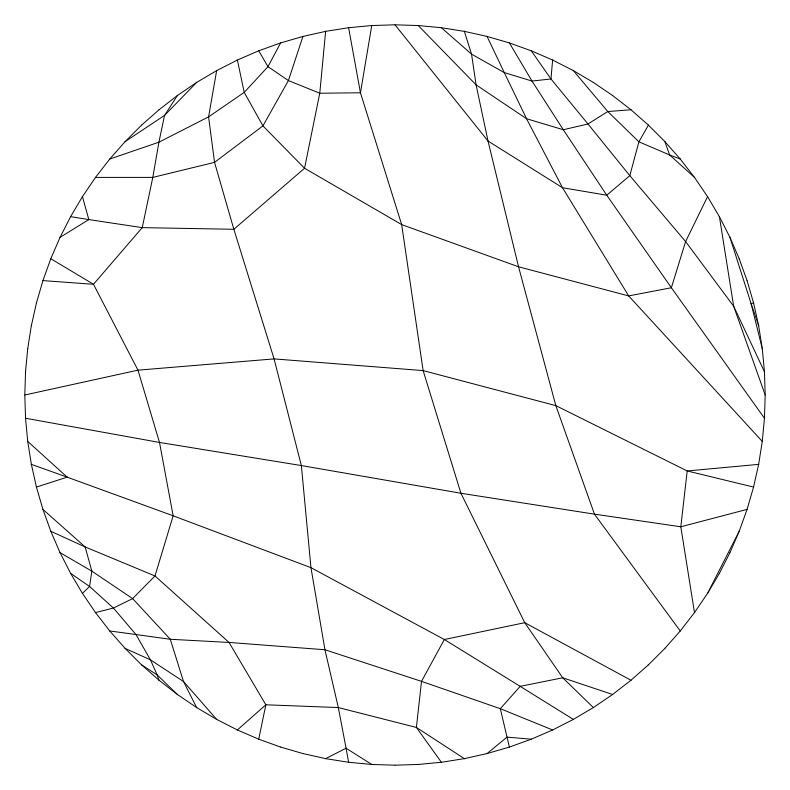

In [22]:
trial(100)